# Constrained Robotics Control
# Assignment 1

## Initial imports

In [ ]:
# !pip install uaibot
# !pip install numpy
# !pip install ipywidgets  # Required for interactive matplotlib plots
# !pip install ipympl

In [1]:
import uaibot as ub
import numpy as np
import matplotlib.pyplot as plt
import random

In [2]:
%matplotlib widget

In [3]:
total_time = 10
dt = 0.01 # Control frequency
steps = int(total_time/dt)

In [4]:
# Useful functions for the assignment
def task_fun(_robot, _q, _htm_tg_t):

    n = np.shape(_q)[0]

    jac, htm_e = _robot.jac_geo(_q)

    x = htm_e[0:3,0]
    y = htm_e[0:3,1]
    z = htm_e[0:3,2]
    s = htm_e[0:3,3]

    xd = _htm_tg_t[0:3,0]
    yd = _htm_tg_t[0:3,1]
    zd = _htm_tg_t[0:3,2]
    sd = _htm_tg_t[0:3,3]

    jac_v = jac[0:3,:]
    jac_w = jac[3:6,:]

    r = np.matrix(np.zeros((6,1)))

    r[0:3,0] = s-sd
    r[3,0] = 1-xd.T*x
    r[4,0] = 1-yd.T*y
    r[5,0] = 1-zd.T*z
    
    # r[3,0] = np.ravel(1-np.dot(xd.T, x))[0]
    # r[4,0] = np.ravel(1-np.dot(yd.T, y))[0]
    # r[5,0] = np.ravel(1-np.dot(zd.T, z))[0]

    jac_r = np.matrix(np.zeros((6,n)))

    jac_r[0:3,:] = jac_v
    jac_r[3,:] = xd.T*ub.Utils.S(x)*jac_w
    jac_r[4,:] = yd.T*ub.Utils.S(y)*jac_w
    jac_r[5,:] = zd.T*ub.Utils.S(z)*jac_w

    return r, jac_r


def fun_phi(_r):
    K = 2.0
    _r_mod = np.matrix(np.zeros((6,1)))

    for i in range(6):
        _r_mod[i,0] = -K*np.sqrt(_r[i,0]) if _r[i,0]>=0 else K*np.sqrt(-_r[i,0])

    return _r_mod


def adjust_control_input(_robot, _q, _u):
    q_min, q_max = get_joint_limits(_robot)
    for i in range(len(_q)):
        if _q[i] + _u[i]*dt <= q_min[i] or _q[i] + _u[i]*dt >= q_max[i]:
            _u[i] = 0 # set joint velocity to zero if joint limit is violated
    return _u

def compute_control(_q, _t, _robot, _htm_tg, check_joint_limits=False):
    
    htm_tg_t = _htm_tg(_t)
    htm_tg_t_plus = _htm_tg(_t+dt)
    htm_tg_t_minus = _htm_tg(_t-dt)

    r, jac_r = task_fun(_robot, _q, htm_tg_t)
    r_plus, _ = task_fun(_robot, _q, htm_tg_t_plus)
    r_minus, _ = task_fun(_robot, _q, htm_tg_t_minus)

    ff = (r_plus-r_minus)/(2*dt)

    u = ub.Utils.dp_inv(jac_r, 0.01)*(fun_phi(r)-1*ff)

    # if check_joint_limits:
    #     u = adjust_control_input(_robot, _q, u)

    return u


def measure_config(_robot):
    return _robot.q


def get_joint_limits(_robot):
    q_min = _robot.joint_limit[:,0]
    q_max = _robot.joint_limit[:,1]
    return q_min, q_max


def send_joint_velocity(_robot, _u, _t):
    dt = 0.01
    qprox = _robot.q + _u*dt
    _robot.add_ani_frame(time=_t+dt, q = qprox)


In [5]:
# Create robots
kuka = ub.Robot.create_kuka_lbr_iiwa()
tx60 = ub.Robot.create_staubli_tx60()

## PROBLEM 1

The kinematic control technique to achieve a target pose can violate the robot's joint limits, that can be obtained as follows:

```python
import uaibot as ub

# Create the robot
robot = ub.Robot.create_kuka_kr5()
# Extract the limits as (n,1)-shaped numpy matrices:
q_min = robot.joint_limit[:,0]
q_max = robot.joint_limit[:,1]

print("q_min = "+str(q_min.transpose()))
print("q_max = "+str(q_max.transpose()))
```

### 1) Implement an UAIBot script to converge to a sequence of random poses. To guarantee joint limits, set the joint velocity of the joint to zero when it is close to violate the respective joint limit. Observe how often this strategy works.

In [ ]:
amplitude = 0.5
wn = 0.25 # natural frequency

xlim = [-0.25, 0.25]
ylim = [-0.25, 0.25]
zlim = [0.3, 0.4]
v_axis = [0, 0, 0] # axis to move
num_targets = 3
htm_fn_list = []
v_axis_list = []
for i in range(num_targets):
    x_rand = random.uniform(xlim[0], xlim[1])
    y_rand = random.uniform(ylim[0], ylim[1])
    z_rand = random.uniform(zlim[0], zlim[1])
    sin_t = lambda _t: amplitude*np.sin(wn*2*np.pi*_t)
    
    # random axis to move
    v_axis[:] = [random.randint(0, 1), random.randint(0, 1), random.randint(0, 1)]
    # print("v_axis = {}".format(v_axis))
    fn = lambda _t: ub.Utils.trn([x_rand+v_axis[0]*sin_t(_t), y_rand+v_axis[1]*sin_t(_t), z_rand+v_axis[2]*sin_t(_t)])
    # print("fn = \n{}".format(fn(0)))
    v_axis_list.append(v_axis.copy())  # Make a copy of v_axis
    # Capture the current values by creating a closure with default arguments
    htm_fn_list.append(lambda _t, x=x_rand, y=y_rand, z=z_rand, v=v_axis.copy(): 
                      ub.Utils.trn([x+v[0]*sin_t(_t), y+v[1]*sin_t(_t), z+v[2]*sin_t(_t)]))

In [ ]:
#Control loop
t = 0

wait_time_sec = 5
move_time_sec = 10

frame = ub.Frame(htm = htm_fn_list[0](0), size = 0.3) # fisrt target in first position
sim = ub.Simulation([kuka, frame])

for idx, htm_fn in enumerate(htm_fn_list):
    
    # print("Current target: {}".format(htm_fn(0)))
    # print("Current v_axis: {}".format(v_axis_list[idx]))
    # Add 'wait' frames
    for i in range(int(wait_time_sec/dt)): # 5sec
        frame.add_ani_frame(time=t, htm = htm_fn(t))
        # dont't increment time

    for i in range(int(move_time_sec/dt)): # 10sec

        q = measure_config(kuka)
        u = compute_control(q, t, kuka, htm_fn, check_joint_limits=True)
        send_joint_velocity(kuka, u, t)

        frame.add_ani_frame(time=t, htm = htm_fn(t))
        t+=dt

sim.run()

As expected, this approach prevents the robot from following targets which go throught the robot's own body.

## PROBLEM 2

### 2.1) Use UAIBot and kinematic control to make a manipulator track a circle drawn in the surface of a sphere. The robot's end-effector should always be normal to the surface of the sphere. You can select the robot, the shape and position of the sphere and the circle inside it, how fast the circle should be tracked, the task function, etc....

In [ ]:
def plot_htm_trajectory(htm_fn, total_time, dt):
    """
    Plots a 3D line following a series of HTMs generated by htm_fn(t) for t in [0, total_time].
    Also plots RGB coordinate frames representing the rotation of the HTM at up to 10 points.
    Args:
        htm_fn: lambda function that takes time t and outputs a 4x4 HTM.
        total_time: total time to sample from.
        dt: time step.
    """
    times = np.arange(0, total_time, dt)
    xs, ys, zs = [], [], []
    for t in times:
        htm = htm_fn(t)
        pos = htm[0:3, 3]
        xs.append(pos[0])
        ys.append(pos[1])
        zs.append(pos[2])

    # Create figure with interactive backend
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot(xs, ys, zs, label='Trajectory', linewidth=2)
    ax.scatter(xs[0], ys[0], zs[0], color='green', s=100, label='Start')
    ax.scatter(xs[-1], ys[-1], zs[-1], color='red', s=100, label='End')
    
    # Plot RGB coordinate frames at up to 10 points along the trajectory
    num_frames = min(10, len(times))
    frame_indices = np.linspace(0, len(times)-1, num_frames, dtype=int)
    frame_scale = 0.05  # Scale factor for the coordinate frame arrows
    
    for idx in frame_indices:
        t = times[idx]
        htm = htm_fn(t)
        pos = htm[0:3, 3]
        
        # Extract rotation matrix (3x3 upper-left part of HTM)
        R = htm[0:3, 0:3]
        
        # Plot X axis (red)
        x_end = pos + R[:, 0] * frame_scale
        ax.plot([pos[0], x_end[0]], [pos[1], x_end[1]], [pos[2], x_end[2]], 'r-', linewidth=2)
        
        # Plot Y axis (green)
        y_end = pos + R[:, 1] * frame_scale
        ax.plot([pos[0], y_end[0]], [pos[1], y_end[1]], [pos[2], y_end[2]], 'g-', linewidth=2)
        
        # Plot Z axis (blue)
        z_end = pos + R[:, 2] * frame_scale
        ax.plot([pos[0], z_end[0]], [pos[1], z_end[1]], [pos[2], z_end[2]], 'b-', linewidth=2)
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title('Line Following HTM Trajectory with RGB Coordinate Frames')
    ax.legend()
    
    # Enable interactive features
    ax.grid(True)
    ax.view_init(elev=20, azim=45)  # Set initial viewing angle
    
    # Ensure the plot is displayed with interactive features
    plt.tight_layout()
    plt.show()
    
    # Return the figure and axis for further manipulation if needed
    return fig, ax

In [ ]:
def plot_sphere_and_vectors(fig=None, ax=None, center=None, n=None, v1=None, v2=None, radius=0.1, vector_scale=0.2):
    """
    Plot the center of a sphere and three vectors (n, v1, v2).
    
    Args:
        center: 3D position of sphere center (3x1 numpy array or list)
        n: normal vector (3x1 numpy array or list)
        v1: first tangent vector (3x1 numpy array or list)
        v2: second tangent vector (3x1 numpy array or list)
        radius: radius of the sphere (float)
        vector_scale: scale factor for vector visualization (float)
    """
    # Convert inputs to numpy arrays if needed
    center = np.array(center).flatten()
    n = np.array(n).flatten()
    v1 = np.array(v1).flatten()
    v2 = np.array(v2).flatten()
    
    # Normalize vectors
    n = n / np.linalg.norm(n)
    v1 = v1 / np.linalg.norm(v1)
    v2 = v2 / np.linalg.norm(v2)
    
    # Create figure
    if fig is None:
        fig = plt.figure(figsize=(12, 10))
    if ax is None:
        ax = fig.add_subplot(111, projection='3d')
    
    # Plot sphere center
    ax.scatter(center[0], center[1], center[2], color='black', s=100, label='Sphere Center')
    
    # Plot sphere (wireframe)
    u = np.linspace(0, 2 * np.pi, 20)
    v = np.linspace(0, np.pi, 20)
    x_sphere = center[0] + radius * np.outer(np.cos(u), np.sin(v))
    y_sphere = center[1] + radius * np.outer(np.sin(u), np.sin(v))
    z_sphere = center[2] + radius * np.outer(np.ones(np.size(u)), np.cos(v))
    ax.plot_surface(x_sphere, y_sphere, z_sphere, alpha=0.25, color='lightblue')
    
    # Plot vectors from center
    # Vector v1 (red)
    v1_end = center + v1 * vector_scale
    ax.quiver(center[0], center[1], center[2], 
              v1[0] * vector_scale, v1[1] * vector_scale, v1[2] * vector_scale,
              color='red', linewidth=3, label=f'Vector v1', arrow_length_ratio=0.1)
    
    # Vector v2 (green)
    v2_end = center + v2 * vector_scale
    ax.quiver(center[0], center[1], center[2], 
              v2[0] * vector_scale, v2[1] * vector_scale, v2[2] * vector_scale,
              color='green', linewidth=3, label=f'Vector v2', arrow_length_ratio=0.1)
    
    # Normal vector n (blue)
    n_end = center + n * vector_scale
    ax.quiver(center[0], center[1], center[2], 
              n[0] * vector_scale, n[1] * vector_scale, n[2] * vector_scale,
              color='blue', linewidth=3, label=f'Normal vector n', arrow_length_ratio=0.1)
    
    
    # Add labels for vector endpoints
    ax.text(v1_end[0], v1_end[1], v1_end[2], 'v1', fontsize=12, color='red')
    ax.text(v2_end[0], v2_end[1], v2_end[2], 'v2', fontsize=12, color='green')
    ax.text(n_end[0], n_end[1], n_end[2], 'n', fontsize=12, color='blue')
    
    # Set labels and title
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title('Sphere Center and Vectors (n, v1, v2)')
    ax.legend()
    
    # Set equal aspect ratio
    ax.set_box_aspect([1,1,1])
    
    # Enable interactive features
    ax.grid(True)
    ax.view_init(elev=20, azim=45)
    
    plt.tight_layout()
    plt.show()
    
    return fig, ax


In [ ]:
# Build circle function
x_rand = random.uniform(0.3, 0.6)
y_rand = random.uniform(0.3, 0.6)
z_rand = random.uniform(0.3, 0.6)
center = ub.Utils.trn([x_rand, y_rand, z_rand])
r = random.uniform(0.1, 0.2) # radius

# Create arbitrary vectors for direction of circle
# Create random normal vector
# n = np.random.rand(3)
n = np.array([1,0,0])
n = n / np.linalg.norm(n)

# Arbitrary vector not parallel to n
a = np.array([1, 0, 0]) if abs(n[0]) < 0.9 else np.array([0, 1, 0])

# Create vector orthogonal to n and a
v1 = np.cross(n, a)
v1 = v1 / np.linalg.norm(v1) # normalize

# make v2 orthogonal to v1
v2 = np.cross(n, v1)
v2 = v2 / np.linalg.norm(v2) # normalize

sphere_rot = np.eye(4) # identity rotation
sphere_rot[0:3,0] = v1
sphere_rot[0:3,1] = v2
sphere_rot[0:3,2] = n

# Create circle function
circle_trn = lambda _t: ub.Utils.trn(center[0:3,3] + np.array([r*(np.cos(_t*2*np.pi/total_time)*v1 + np.sin(_t*2*np.pi/total_time)*v2)]).T)*sphere_rot
circle_rot = lambda _t: sphere_rot*ub.Utils.rot(n, (_t/total_time)*2*np.pi)*ub.Utils.rot([1,0,0], np.pi)
circle_htm =  lambda _t: circle_trn(_t)*circle_rot(_t)

# Print vectors
print("v1 = ", v1)
print("v2 = ", v2)
print("n = ", n)
print("a = ", a)
print("v1 dot v2 = ", np.dot(v1, v2))
print("center = \n", center[0:3,3])
print("circle_trn(np.pi/2) = \n", circle_trn(np.pi/2))
print("circle_rot(np.pi/2) = \n", circle_rot(np.pi/2))
print("circle_htm(np.pi/2) = \n", circle_htm(np.pi/2))

In [ ]:
fig, ax = plot_htm_trajectory(circle_htm, total_time, dt)
fig, ax = plot_sphere_and_vectors(fig, ax, center[0:3,3], n, v1, v2, radius=r, vector_scale=0.08)

In [ ]:
# Control loop
kuka = ub.Robot.create_kuka_lbr_iiwa()
t = 0
total_sim_time = total_time*2

frame = ub.Frame(htm = circle_htm(0), size = 0.1) # fisrt target in first position
sphere = ub.simobjects.ball.Ball(htm=center, radius=r, opacity=0.2)
path_pts = [
    circle_htm(ti)[:3,3] for ti in np.linspace(0, total_sim_time, int(total_sim_time/dt))
]

pc = ub.simobjects.PointCloud(
    name="path",
    points=path_pts,   # expects 3 x N
    size=0.02,
    color="yellow"
)

sim = ub.Simulation([kuka, frame, sphere, pc])
times, errors = [], []
qs = []

for i in range(int(total_sim_time/dt)):
        
    circle_htm_t = circle_htm(t) # Current target
    frame.add_ani_frame(time=t, htm = circle_htm_t)
    
    q = measure_config(kuka)
    qs.append(q)
    u = compute_control(q, t, kuka, circle_htm, check_joint_limits=False)
    send_joint_velocity(kuka, u, t)

    frame.add_ani_frame(time=t, htm = circle_htm_t)
    pc.add_ani_frame(time=t, initial_ind=0, final_ind=i)

    eff_pose = kuka.fkm(q) # FK for current configuration
    times.append(t)
    errors.append(np.linalg.norm(circle_htm_t[:3,3] - eff_pose[:3,3]))
    
    t+=dt

times = np.array(times)
errors = np.array(errors)

sim.run()

### 2.2) Plot the task error as a function of time.

In [ ]:
errors = np.round(errors, 4)
print(errors)

plt.clf()
# plt.figure(figsize=(8,4))
plt.plot(times, errors, label='Task Error')
plt.xlabel('Time [s]')
plt.ylabel('Task Space Error')
plt.title('Task Error vs Time')
plt.grid(True)
plt.legend()
# plt.tight_layout()
plt.show()



### 2.3) Plot the graph of configuration for each joint, along with the joint limits. Verify if the joint limits are violated (you dont have to do anything about it, just verify).

In [ ]:
# Plot each joint over time and the joint limits

qs_arr = np.array(qs)  # shape: (timesteps, num_joints)
num_joints = qs_arr.shape[1] if qs_arr.ndim > 1 else 1

fig, axes = plt.subplots(num_joints, 1, figsize=(10, 2*num_joints), sharex=True)

if num_joints == 1:
    axes = [axes]

for i in range(num_joints):
    axes[i].plot(times, qs_arr[:, i], label=f'Joint {i+1} position')
    axes[i].hlines(kuka.joint_limit[i, 0], times[0], times[-1], colors='r', linestyles='dashed', label='Lower Limit')
    axes[i].hlines(kuka.joint_limit[i, 1], times[0], times[-1], colors='g', linestyles='dashed', label='Upper Limit')
    axes[i].set_ylabel(f'Joint {i+1} (rad)')
    axes[i].legend(loc='upper right')
    axes[i].grid(True)

axes[-1].set_xlabel('Time [s]')
plt.suptitle("Joint Position vs Time with Joint Limits")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


## PROBLEM 3

- Model the Staubli TX60 robot (created using Robot.create_staubli_tx60 ) using spheres. That is, specify the number of spheres and their radiuses for each link, and then provide the transformation from the Denavir-Hartenberg frame to each one of the objects' frame.

- You need to create a script that, given a generic configuration, shows how the spheres are in the space to cover the robot when it is in this configuration.

In [ ]:
def get_robot_spheres(_robot, spheres_config=None, q=None):
    """
    Plots the robot with spheres representing each link.
    
    Args:
        _robot: The robot object
        spheres_config: List of list of dictionaries representing the spheres for each link.
        Each list inside the main list contains dictionaries with the following keys:
            - 'radius': The radius of the sphere
            - 'htm': The transformation from the Denavir-Hartenberg frame to the sphere's frame
            - 'color': The color of the sphere
        q: The configuration of the robot
    """
    if q is None:
        q = measure_config(_robot)
    
    # Get all links transforms
    links_htm = _robot.fkm(q, axis='dh')

    num_links = len(links_htm) + 1 # +1 for the base

    if len(spheres_config) != num_links:
        raise ValueError(f"The number of spheres_config must be equal to the number of links (including the base): {num_links} != {len(spheres_config)}")

    robot_spheres = [
        [] for _ in range(num_links)
    ]
    for link_idx, link_spheres in enumerate(spheres_config):
        for link_sphere in link_spheres:
            radius = link_sphere.get('radius', None)
            sphere_htm = link_sphere.get('htm', None)
            color = link_sphere.get('color', None)
            opacity = link_sphere.get('opacity', 0.2)
            if radius is None:
                raise ValueError("radius must be provided")
            if sphere_htm is None:
                raise ValueError("sphere_htm must be provided")
            if color is None:
                color = 'gray'

            if link_idx == 0:
                # Base sphere
                robot_spheres[link_idx].append(ub.simobjects.ball.Ball(htm=sphere_htm, radius=radius, opacity=opacity, color=color))
                continue
            
            # Get world htm
            link_htm = links_htm[link_idx-1]
            world_htm = link_htm*sphere_htm
            
            # Create sphere object and append to list
            sphere = ub.simobjects.ball.Ball(htm=world_htm, radius=radius, opacity=opacity, color=color)    
        
            # Set initial frame
            sphere.add_ani_frame(time=0, htm=world_htm)

            robot_spheres[link_idx].append(sphere) #.copy()

            # print("sphere htm = \n",sphere.htm)


    return robot_spheres


In [ ]:
opacity = 0.35
spheres_config = [
    # Link 0 (base)
    [{
        'radius': 0.13,
        'htm': ub.Utils.trn([0, 0, 0.1]),
        'color': 'red',
        'opacity': opacity
    }],
    # Link 1
    [{
        'radius': 0.2,
        'htm': ub.Utils.trn([0, -0.12, 0]),
        'color': 'green',
        'opacity': opacity
    }],
    # Link 2
    [{
        'radius': 0.2,
        'htm': ub.Utils.trn([-0.2, 0, -0.05]),
        'color': 'blue',
        'opacity': opacity
    }],
    # Link 3
    [{
        'radius': 0.1,
        'htm': ub.Utils.trn([0.0, 0.0, 0.0]),
        'color': 'yellow',
        'opacity': opacity
    },
    {
        'radius': 0.1,
        'htm': ub.Utils.trn([0.0, -0.10, 0.0]),
        'color': 'yellow',
        'opacity': opacity
    }
    ],
    # Link 4
    [{
        'radius': 0.1,
        'htm': ub.Utils.trn([0.0, -0.05, 0]),
        'color': 'purple',
        'opacity': opacity
    },
    {
        'radius': 0.1,
        'htm': ub.Utils.trn([0.0, -0.2, 0]),
        'color': 'purple',
        'opacity': opacity
    }
    ],
    # Link 5
    [{
        'radius': 0.01,
        'htm': np.eye(4),
        'color': 'orange',
        'opacity': opacity
    }],
    # Link 6
    [{
        'radius': 0.03,
        'htm': np.eye(4),
        'color': 'cyan',
        'opacity': opacity
    }],
]

In [ ]:
def update_robot_spheres(_robot, t, robot_spheres, spheres_config):
    """
    Updates the robot spheres to the current configuration of the robot at time t.
    
    Args:
        _robot: The robot object
        robot_spheres: List of list of sphere objects for each link.
        t: The time to add the animation frame
    """
    q = measure_config(_robot)
    
    # Get all links transforms
    links_htm = _robot.fkm(q, axis='dh')

    num_links = len(links_htm) + 1 # +1 for the base

    if len(robot_spheres) != num_links:
        raise ValueError(f"The number of robot_spheres must be equal to the number of links (including the base): {num_links} != {len(robot_spheres)}")

    for link_idx, link_spheres in enumerate(robot_spheres):
        link_htm = links_htm[link_idx-1]
        for sphere_idx, sphere in enumerate(link_spheres):
            if link_idx == 0: # Base sphere
                sphere.add_ani_frame(time=t, htm = sphere.htm)
                continue
            
            # Get world htm
            local_sphere_htm = spheres_config[link_idx][sphere_idx]['htm']
            world_htm = link_htm*local_sphere_htm
            
            sphere.add_ani_frame(time=t, htm=world_htm)

In [ ]:
robot_spheres = get_robot_spheres(tx60, spheres_config)

sim_objs = [tx60]
sim_objs.extend(robot_spheres)

sim = ub.Simulation(
    sim_objs,
    # width=1600,
    # height=1000,
    )

# Create linspace for all joints
steps = int(total_time/dt)
q_min, q_max = tx60.joint_limit[:, 0], tx60.joint_limit[:, 1]
q_min, q_max = q_min.transpose(), q_max.transpose()
q = np.array([np.linspace(qmin, qmax, steps) for qmin, qmax in zip(q_min, q_max)])
q = q.squeeze()

for i in range(steps):
    t = i/steps*total_time
    tx60.add_ani_frame(time=t, q = q[i])
    update_robot_spheres(tx60, t, robot_spheres, spheres_config)
    
    
sim.run()

## PROBLEM 4

- You can create generic convex polygons in UAIBot by specifing the inequality Ap <= b that generates them and then calling the ConvexPolytope constructor.

- A should be a (nx3) np.matrix, whereas b should be a (nx1) np.matrix. For example:


```python
import uaibot as ub

#Lets create a cube with sides 1 centered at (0,0,4)
#It is generated by the inequalities
#x <= 1, x>=-1, y<=1, y>=-1, z<=5, z>=3
#Writing as a <= inequality:
#x <= 1, -x<=1, y<=1, -y<=1, z<=5, -z<=-3
A = np.matrix([[1,0,0],[-1,0,0],[0,1,0],[0,-1,0],[0,0,1],[0,0,-1]])
b = np.matrix([[1],[1],[1],[1],[5],[-3]])

#Create the object
obj = ub.ConvexPolytope(A=A,b=b,color='red')

#Show (assuming Google Colab)
sim = ub.Simulation([obj])
sim.run()
```

- Create a script to draw in the screen (at the same time) all the other four Platonic Solids.

In [6]:
def generate_platonic_solid(faces_vertices):
    """
    Generates a platonic solid in 3D given its vertices and a point inside the solid.
    """
    
    num_faces, num_vertices_per_face, num_dims = faces_vertices.shape

    # Get all unique vertices in the faces_vertices array and compute their average
    unique_vertices = np.unique(faces_vertices.reshape(-1, faces_vertices.shape[-1]), axis=0)
    p_inside = np.mean(unique_vertices, axis=0).reshape((3,1))

    if num_dims != 3:
        raise ValueError("Vertices must be in 3D.")
    
    # if num_vertices < 4:
    #     raise ValueError("At least 4 vertices are required to define a platonic solid.")
    
    # if num_faces is None or num_faces < num_vertices:
    #     raise ValueError("Number of faces must be at least equal to the number of vertices.")

    A_matrix = np.zeros((num_faces, num_dims))
    b_vector = np.zeros((num_faces, 1))
    num_ineq = 0

    # Initialize selected vectors
    num_runs = 0
    for face_vertices in faces_vertices:
        num_runs += 1
        idx = []
        while len(set(idx)) != 3:
            idx = np.random.randint(0, len(face_vertices), size=3)

        # Create 2 vectors from the 3 points
        a = face_vertices[idx[0],:].reshape(num_dims,1)
        b = face_vertices[idx[1],:].reshape(num_dims,1)
        c = face_vertices[idx[2],:].reshape(num_dims,1)
        v1 = b - a
        v2 = c - a

        # print(f"Points: \na={a}, \nb={b}, \nc={c}")
        # print("a.shape = {}, b.shape = {}, c.shape = {}".format(a.shape, b.shape, c.shape))
        # print(f"Vectors: v1=\n{v1}, v2=\n{v2}")

        # # print shapes
        # print("v1.shape = ", v1.shape)
        # print("v2.shape = ", v2.shape)
        
        
        # Compute normal vector
        n = np.cross(v1.T, v2.T)
        # n = n / np.linalg.norm(n)
        
        # Reshape n to num_dims x 1
        n = n.reshape(num_dims,1)


        ineq_test = n.T @ (p_inside - a) # make sure n points outside the solid
        ineq_test = ineq_test.squeeze()
        
        sign = -1 if ineq_test >= 0 else 1
        n = n*sign

        A = n.T
        b = n.T @ a
        # Squeeze
        b = b.squeeze()


        if any(np.allclose(A, A_matrix[i]) and np.allclose(b, b_vector[i]) for i in range(num_ineq)):
            print("-" * 40)
            print(f"Inequality {A} <= {b} already exists, skipping...")
            print("-" * 40)
            continue
        
        if np.all(A == 0):
            print("All elements of A are zero, continuing to next iteration.")
            continue

        A_matrix[num_ineq] = A
        b_vector[num_ineq] = b
        num_ineq += 1


    # Remove rows of all zeros from A_matrix and the corresponding entries from b_vector (keep only filled rows)
    A_matrix = A_matrix[:num_ineq]
    b_vector = b_vector[:num_ineq]

    # print("-" * 40)
    # print("After removing rows of all zeros:")
    # print("A_matrix = \n", A_matrix)
    # print("b_vector = \n", b_vector)
    # print("-" * 40)

    return A_matrix, b_vector




In [7]:
def get_dodecahedron_vertices():
    # Golden ratio
    phi = (1 + np.sqrt(5)) / 2

    # Unscaled vertices (standard coordinates for a dodecahedron)
    vertices = np.array([
        # 8 vertices with coordinates (±1, ±1, ±1)
        [+1, +1, +1], [+1, +1, -1], [+1, -1, +1], [+1, -1, -1],
        [-1, +1, +1], [-1, +1, -1], [-1, -1, +1], [-1, -1, -1],
        # 12 vertices with coordinates (0, ±1/φ, ±φ) and cyclic permutations
        [0, +1/phi, +phi], [0, +1/phi, -phi], [0, -1/phi, +phi], [0, -1/phi, -phi],
        [+1/phi, +phi, 0], [+1/phi, -phi, 0], [-1/phi, +phi, 0], [-1/phi, -phi, 0],
        [+phi, 0, +1/phi], [+phi, 0, -1/phi], [-phi, 0, +1/phi], [-phi, 0, -1/phi]
    ])

    # Normalize to unit edge length
    # Compute the length of one known edge and rescale
    edge_length = np.linalg.norm(vertices[0] - vertices[8])  # any adjacent pair works
    scale = 1.0 / edge_length
    vertices *= scale

    v0, v1, v2, v3, v4, v5, v6, v7, v8, v9, v10, v11, v12, v13, v14, v15, v16, v17, v18, v19 = vertices

    faces_vertices = np.array([
        [v0, v8, v4, v14, v12],
        [v0, v8, v10, v2, v16],
        [v0, v12, v1, v17, v16],
        [v1, v9, v5, v14, v12],
        [v1, v9, v11, v3, v17],
        [v2, v10, v6, v15, v13],
        [v2, v13, v3, v17, v16],
        [v3, v11, v7, v15, v13],
        [v4, v8, v10, v6, v18],
        [v4, v14, v5, v19, v18],
        [v5, v9, v11, v7, v19],
        [v6, v15, v7, v19, v18],       
    ])

    return faces_vertices

In [8]:
def get_icosahedron_vertices():
    from itertools import combinations

    # ---- 1) Icosahedron vertices (unscaled) ----
    phi = (1 + np.sqrt(5)) / 2  # golden ratio

    verts = np.array([
        [0,  1,  phi], [0, -1,  phi], [0,  1, -phi], [0, -1, -phi],
        [ 1,  phi, 0], [-1,  phi, 0], [ 1, -phi, 0], [-1, -phi, 0],
        [ phi, 0,  1], [ phi, 0, -1], [-phi, 0,  1], [-phi, 0, -1]
    ], dtype=float)

    # ---- 2) Scale so that edge length = 1 ----
    # Any edge pair works; 0 and 1 are adjacent in this layout
    edge_len = np.linalg.norm(verts[0] - verts[1])
    verts /= edge_len

    # ---- 3) Enumerate vertices ----
    # print("Vertex indices and coordinates (edge length = 1):")
    # for i, v in enumerate(verts):
    #     print(f"{i}: {v}")

    # ---- 4) Compute faces from unit-edge adjacencies ----
    # Build adjacency: i ~ j if ||vi - vj|| == 1 (within tolerance)
    tol = 1e-6
    n = len(verts)

    adj = {i: set() for i in range(n)}
    for i, j in combinations(range(n), 2):
        if abs(np.linalg.norm(verts[i] - verts[j]) - 1.0) < tol:
            adj[i].add(j)
            adj[j].add(i)

    # Each face is a triangle (i, j, k) where all three pairs are adjacent
    faces_set = set()
    for i in range(n):
        # consider pairs of neighbors of i
        for j, k in combinations(sorted(adj[i]), 2):
            if j in adj[k]:  # j and k also adjacent -> triangle
                tri = tuple(sorted((i, j, k)))
                faces_set.add(tri)

    faces = sorted(list(faces_set))

    # print("\nFaces (each as a list of vertex indices):")
    # for f in faces:
    #     print(list(f))

    # print(f"\nTotal faces: {len(faces)} (expected 20)")

    # return verts
    faces_vertices = []
    for face in faces:
        face_vertices = []
        for i in face:
            face_vertices.append(verts[i])
        faces_vertices.append(face_vertices)
    
    faces_vertices = np.array(faces_vertices)
    # print("faces_vertices.shape = ", faces_vertices.shape)

    return faces_vertices
    


In [9]:
def Cube(color,opacity, offset=[]):
    offset = np.array(offset)

    v1 = np.array([1, 1, 1])
    v2 = np.array([1, 1, -1])
    v3 = np.array([1, -1, 1])
    v4 = np.array([1, -1, -1])
    v5 = np.array([-1, 1, 1])
    v6 = np.array([-1, 1, -1])
    v7 = np.array([-1, -1, 1])
    v8 = np.array([-1, -1, -1])
    faces_vertices = np.array([
        [v1, v2, v3, v4],
        [v1, v2, v5, v6],
        [v3, v4, v7, v8],
        [v2, v4, v6, v8],
        [v5, v6, v7, v8],
        [v1, v3, v5, v7],
    ]) + offset
    A, b = generate_platonic_solid(faces_vertices)
    return ub.ConvexPolytope(A=A,b=b,color=color, opacity=opacity)

def Tetrahedron(color,opacity, offset=[]):
    offset = np.array(offset)
    v1 = [0, 0, 1]
    v2 = [1, 1, 0]
    v3 = [1, -1, 0]
    v4 = [-1, -1, 0]
    faces_vertices = np.array([
        [v1, v2, v3],
        [v1, v2, v4],
        [v1, v3, v4],
        [v2, v3, v4],
    ]) + offset
    A, b = generate_platonic_solid(faces_vertices)
    return ub.ConvexPolytope(A=A,b=b,color=color, opacity=opacity)

# Octaheron
def Octahedron(color,opacity, offset=[]):
    offset = np.array(offset)
    
    v1 = np.array([0, 0, 2])
    v2 = np.array([1, 1, 0])
    v3 = np.array([1, -1, 0])
    v4 = np.array([-1, 1, 0])
    v5 = np.array([-1, -1, 0])
    v6 = np.array([0, 0, -2])
    faces_vertices = np.array([
        [v1, v2, v3],
        [v1, v2, v4],
        [v1, v3, v5],
        [v1, v4, v5],
        [v2, v4, v6],
        [v2, v3, v6],
        [v3, v5, v6],
        [v4, v5, v6],
        
    ]) + offset
    A, b = generate_platonic_solid(faces_vertices)
    return ub.ConvexPolytope(A=A,b=b,color=color, opacity=opacity)

# Dodecahedron
def Dodecahedron(color,opacity, offset=[]):
    
    offset = np.array(offset)
    faces_vertices = get_dodecahedron_vertices() + offset
    A, b = generate_platonic_solid(faces_vertices)
    return ub.ConvexPolytope(A=A,b=b,color=color, opacity=opacity)

# Icosahedron
def Icosahedron(color,opacity, offset=[]):
    offset = np.array(offset)
    # v0, v1, v2, v3, v4, v5, v6, v7, v8, v9, v10, v11 = get_icosahedron_vertices()
    # faces_vertices = np.array([
    #     [v0, v1, v8],
    #     [v0, v1, v10],
    #     [v0, v4, v5],
    #     [v0, v4, v8],
    #     [v0, v5, v10],
    #     [v1, v6, v7],
    #     [v1, v6, v8],
    #     [v1, v7, v10],
    #     [v2, v3, v9],
    #     [v2, v3, v11],
    #     [v2, v4, v5],
    #     [v2, v4, v9],
    #     [v2, v5, v11],
    #     [v3, v6, v7],
    #     [v3, v6, v9],
    #     [v3, v7, v11],
    #     [v4, v8, v9],
    #     [v5, v10, v11],
    #     [v6, v8, v9],
    #     [v7, v10, v11],
    # ]) + offset
    faces_vertices = get_icosahedron_vertices() + offset
    A, b = generate_platonic_solid(faces_vertices)
    return ub.ConvexPolytope(A=A,b=b,color=color, opacity=opacity)

In [10]:
opacity = 0.9
# Get all solids
objs = [
    Cube('orange', opacity=opacity, offset = [-5, -2, 3]),
    Tetrahedron('green', opacity=opacity, offset = [-1., -1, 2.5]),
    Octahedron('blue', opacity=opacity, offset = [1, 2, 3]),
    Dodecahedron('yellow', opacity=opacity, offset = [5, 1, 3]),
    Icosahedron('purple', opacity=opacity, offset = [-3, 3, 3])
]
# Plot all solids
sim = ub.Simulation(
    objs,
    width=800,
    height=800,
    camera_start_pose=[-4, -10, 10, 0, 0, 0, 1]
)

sim.run()

## PROBLEM 5

- Create any convex object (e.g., a sphere) and transform the surface of this object into a PointCloud using the function to_point_cloud:

In [11]:
# Add ani frame for the lidar
def add_animation_lidar_rays(cylinders, points, pc, t):
    for p_idx, point in enumerate(points):
        # print(point)
        box_dim = 0.01
        alpha = 0.95
        aux_point = alpha*point + (1-alpha)*np.array(pc)
        # print("aux_point = ", aux_point)
        ray = ub.simobjects.box.Box(
            htm = ub.Utils.trn(aux_point),
            width = box_dim,
            depth = box_dim,
            height = box_dim
        )
        _, _, dist, _ = ray.compute_dist(sphere)
        # print(f"dist to sphere = {dist}")
        if dist < 1e-5:
            # print("Ray blocked!")
            # Remove ray - set opacity to 0 and add animation frame
            if isinstance(cylinders[p_idx], ub.simobjects.Cylinder):
                cylinders[p_idx].opacity = 0.0
                cylinders[p_idx].add_ani_frame(t, cylinders[p_idx].htm)  # Add animation frame for opacity change
        else:
            # print("Point detected!")
            # Draw a thin cylinder from pc to point
            cyl_radius = 0.005
            # Calculate displacement vector and length
            vec = point - pc
            length = np.linalg.norm(vec)
            if length > 1e-8:
                # Get cylinder frame: translation + rotation to align z with vec
                direction = vec / length
                # Helper function to get rotation matrix aligning z to direction
                def rot_z_to_vec(vec):
                    from scipy.spatial.transform import Rotation as R
                    z = np.array([0, 0, 1])
                    cross = np.cross(z, vec)
                    dot = np.dot(z, vec)
                    if np.allclose(cross, 0):  # already colinear
                        if dot > 0:
                            return np.eye(3)
                        else:
                            return R.from_euler('x', 180, degrees=True).as_matrix()
                    axis = cross / np.linalg.norm(cross)
                    angle = np.arccos(dot)
                    return R.from_rotvec(axis * angle).as_matrix()

                # Set cylinder center frame (midpoint)
                midpoint = (pc + point) / 2
                rot_mat = rot_z_to_vec(direction)
                # Compose 4x4 HTM
                htm = np.eye(4)
                htm[:3, :3] = rot_mat
                htm[:3, 3] = midpoint
                
                if not isinstance(cylinders[p_idx], ub.simobjects.Cylinder):
                    # Create new cylinder
                    cylinders[p_idx] = ub.simobjects.cylinder.Cylinder(
                        htm=htm,
                        radius=cyl_radius,
                        height=length,
                        color="red",
                        opacity=0.2
                    )

                # print("Adding")
                cylinders[p_idx].opacity = 0.2
                cylinders[p_idx].add_ani_frame(t, htm)

In [61]:
import uaibot as ub
import numpy as np

#Create the object
ball_center = [0,0,2]
theta_threshold = 15
print("theta_threshold = ", theta_threshold)
sphere = ub.simobjects.ball.Ball(htm = ub.Utils.trn(ball_center), radius=1)
#Sample using discretization disc=0.25
sphere_pc = sphere.to_point_cloud(disc=0.025)

pc = [2,0,0]
w, d, h = 0.1, 0.1, 0.1 # like in x, y, z
box_opacity = 0.9
box_color = "blue"
frame_size = 0.15
lidar_htm = ub.Utils.trn(pc) * ub.Utils.rot([0,1,0], -np.pi/4)
lidar_z = [lidar_htm[0,2], lidar_htm[1,2], lidar_htm[2,2]]
# print("lidar_z = ", lidar_z)
lidar = ub.simobjects.box.Box(
    htm = lidar_htm,
    width = w,
    depth = d,
    height = h,
    color = box_color,
    opacity = box_opacity
)
frame = ub.simobjects.frame.Frame(
    htm = lidar_htm,
    size = frame_size,
)

points = np.array(sphere_pc.points).T # N x 3
cylinders = [ [] for _ in range(points.shape[0])]

for p_idx, point in enumerate(points):
    # print(point)
    box_dim = 0.01
    alpha = 0.95
    aux_point = alpha*point + (1-alpha)*np.array(pc)
    # print("aux_point = ", aux_point)
    ray = ub.simobjects.box.Box(
        htm = ub.Utils.trn(aux_point),
        width = box_dim,
        depth = box_dim,
        height = box_dim,
        color = "black",
        opacity = box_opacity
    )
    _, _, dist, _ = ray.compute_dist(sphere)
    # print(f"dist to sphere = {dist}")
    if dist < 1e-5:
        # print("Ray blocked!")
        opacity = 0.0
        htm = ub.Utils.trn([0,0,0])
    else:
        # print("Point detected!")
        # Draw a thin cylinder from pc to point
        cyl_radius = 0.005
        # Calculate displacement vector and length
        vec = point - pc
        length = np.linalg.norm(vec)
        if length > 1e-8:
            # Get cylinder frame: translation + rotation to align z with vec
            direction = vec / length
            # Helper function to get rotation matrix aligning z to direction
            def rot_z_to_vec(lidar_z, vec, theta_threshold):
                from scipy.spatial.transform import Rotation as R
                z = lidar_z
                cross = np.cross(z, vec)
                dot = np.dot(z, vec)
                if np.allclose(cross, 0):  # already colinear
                    if dot > 0:
                        return lidar_z #np.eye(3)
                    else:
                        return -lidar_z #R.from_euler('x', 180, degrees=True).as_matrix()
                axis = cross / np.linalg.norm(cross)
                angle = np.arccos(dot)
                # print("angle = ", np.rad2deg(angle))
                if abs(np.rad2deg(angle)) > theta_threshold:
                    return None
                return R.from_rotvec(axis * angle).as_matrix()

            # Set cylinder center frame (midpoint)
            midpoint = (pc + point) / 2
            aux_rot_mat = rot_z_to_vec(lidar_z, direction, theta_threshold)
            if aux_rot_mat is None:
                # print("angle too large")
                continue
            
            rot_mat = lidar_htm[:3, :3] @ aux_rot_mat
            # print("rot_mat = ", rot_mat)
            # Compose 4x4 HTM
            cyl_htm = np.eye(4)
            cyl_htm[:3, :3] = rot_mat
            cyl_htm[:3, 3] = midpoint
            opacity = 0.2

        # cyl = ub.simobjects.cylinder.Cylinder(
        #     htm=cyl_htm,
        #     radius=cyl_radius,
        #     height=length,
        #     color="red",
        #     opacity=opacity
        # )
        cylinders[p_idx] = ub.simobjects.cylinder.Cylinder(
            htm=cyl_htm,
            radius=cyl_radius,
            height=length,
            color="red",
            opacity=opacity
        )

#See the point cloud (assuming Google Colab)
sim = ub.Simulation([sphere_pc, lidar, frame, cylinders],
    width=800,
    height=800,
    camera_start_pose=[2, 5, 5, 0, 0, 0, 1]
)

animate = False

if animate:
    # Move the lidar
    total_time = 10
    dt = 0.1
    r = 2.0
    lidar_pos = lambda t: ub.Utils.trn([2.0*np.cos(np.deg2rad(10*2*np.pi*t)), 2.0*np.sin(np.deg2rad(10*2*np.pi*t)), 0]) * ub.Utils.rot([0,1,0], np.pi/4)

    for i in range(int(total_time/dt)):
        t = i*dt
        # print(f"t = {t}/{total_time}")
        lidar.add_ani_frame(t, lidar_pos(t))
        lidar_htm = np.array(lidar.htm[0:3,3])
        pc_x, pc_y, pc_z = float(lidar_htm[0][0]), float(lidar_htm[1][0]), float(lidar_htm[2][0])
        pc = [pc_x, pc_y, pc_z]
        
        print("new pc = ", pc)
        add_animation_lidar_rays(cylinders, points, pc, t)

sim.run()
                                            

theta_threshold =  15


## PROBLEM 6

- Show if the following functions are convex or not (justify why):

### 6.1) $\ln\left(\frac{e^u + 1}{2}\right)$

In [ ]:
# Plot function 6.1: ln((e^u + 1)/2)
import numpy as np
import matplotlib.pyplot as plt

u = np.linspace(-np.pi, np.pi, 1000)
f1 = np.log((np.exp(u) + 1) / 2)

plt.figure(figsize=(10, 6))
plt.plot(u, f1, 'b-', linewidth=2, label=r'$\ln\left(\frac{e^u + 1}{2}\right)$')
plt.xlabel('u')
plt.ylabel('f(u)')
plt.title('Function 6.1: ln((e^u + 1)/2)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


### 6.2) $u^4 + 10u^3 - 1$


In [ ]:
# Plot function 6.2: u^4 + 10u^3 - 1
u = np.linspace(-np.pi, np.pi, 1000)
f2 = u**4 + 10*u**3 - 1

plt.figure(figsize=(10, 6))
plt.plot(u, f2, 'r-', linewidth=2, label=r'$u^4 + 10u^3 - 1$')
plt.xlabel('u')
plt.ylabel('f(u)')
plt.title('Function 6.2: u^4 + 10u^3 - 1')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


### 6.3) $\frac{1}{2}u^2 + \sin(u)$


In [ ]:
# Plot function 6.3: (1/2)u^2 + sin(u)
u = np.linspace(-np.pi, np.pi, 1000)
f3 = 0.5*u**2 + np.sin(u)

plt.figure(figsize=(10, 6))
plt.plot(u, f3, 'g-', linewidth=2, label=r'$\frac{1}{2}u^2 + \sin(u)$')
plt.xlabel('u')
plt.ylabel('f(u)')
plt.title('Function 6.3: (1/2)u^2 + sin(u)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


### 6.4) $u_1^2 + u_1 u_2 + 4u_2^2$


In [ ]:
# Plot function 6.4: u1^2 + u1*u2 + 4*u2^2
# Create a 2D grid for u1 and u2
u1 = np.linspace(-np.pi, np.pi, 100)
u2 = np.linspace(-np.pi, np.pi, 100)
U1, U2 = np.meshgrid(u1, u2)
f4 = U1**2 + U1*U2 + 4*U2**2

plt.figure(figsize=(10, 8))
contour = plt.contour(U1, U2, f4, levels=20)
plt.clabel(contour, inline=True, fontsize=8)
plt.colorbar(contour)
plt.xlabel('u1')
plt.ylabel('u2')
plt.title('Function 6.4: u1^2 + u1*u2 + 4*u2^2')
plt.grid(True, alpha=0.3)
plt.show()

# Also plot a 3D surface
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(U1, U2, f4, cmap='viridis', alpha=0.8)
ax.set_xlabel('u1')
ax.set_ylabel('u2')
ax.set_zlabel('f(u1, u2)')
ax.set_title('Function 6.4: u1^2 + u1*u2 + 4*u2^2 (3D)')
plt.colorbar(surf)
plt.show()


### 6.5) $u_1^2 + 3u_1 u_2 + u_2^2$


In [ ]:
# Plot function 6.5: u1^2 + 3*u1*u2 + u2^2
# Create a 2D grid for u1 and u2
u1 = np.linspace(-np.pi, np.pi, 100)
u2 = np.linspace(-np.pi, np.pi, 100)
U1, U2 = np.meshgrid(u1, u2)
f5 = U1**2 + 3*U1*U2 + U2**2

plt.figure(figsize=(10, 8))
contour = plt.contour(U1, U2, f5, levels=20)
plt.clabel(contour, inline=True, fontsize=8)
plt.colorbar(contour)
plt.xlabel('u1')
plt.ylabel('u2')
plt.title('Function 6.5: u1^2 + 3*u1*u2 + u2^2')
plt.grid(True, alpha=0.3)
plt.show()

# Also plot a 3D surface
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(U1, U2, f5, cmap='plasma', alpha=0.8)
ax.set_xlabel('u1')
ax.set_ylabel('u2')
ax.set_zlabel('f(u1, u2)')
ax.set_title('Function 6.5: u1^2 + 3*u1*u2 + u2^2 (3D)')
plt.colorbar(surf)
plt.show()


### 6.6) $e^{u_3^2} + \sqrt{u_1^2 + u_2^2}$


In [ ]:
# Plot function 6.6: e^(u3^2) + sqrt(u1^2 + u2^2)
# Create a 2D grid for u1 and u2, with u3 = 0 for visualization
u1 = np.linspace(-np.pi, np.pi, 100)
u2 = np.linspace(-np.pi, np.pi, 100)
U1, U2 = np.meshgrid(u1, u2)
u3 = 0  # Set u3 = 0 for 2D visualization
f6 = np.exp(u3**2) + np.sqrt(U1**2 + U2**2)

plt.figure(figsize=(10, 8))
contour = plt.contour(U1, U2, f6, levels=20)
plt.clabel(contour, inline=True, fontsize=8)
plt.colorbar(contour)
plt.xlabel('u1')
plt.ylabel('u2')
plt.title('Function 6.6: e^(u3^2) + sqrt(u1^2 + u2^2) with u3=0')
plt.grid(True, alpha=0.3)
plt.show()

# Also plot a 3D surface
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(U1, U2, f6, cmap='coolwarm', alpha=0.8)
ax.set_xlabel('u1')
ax.set_ylabel('u2')
ax.set_zlabel('f(u1, u2, u3=0)')
ax.set_title('Function 6.6: e^(u3^2) + sqrt(u1^2 + u2^2) with u3=0 (3D)')
plt.colorbar(surf)
plt.show()

# Also show how the function varies with u3 for fixed u1, u2
u3_range = np.linspace(-np.pi, np.pi, 100)
u1_fixed, u2_fixed = 1, 1  # Fixed values
f6_u3 = np.exp(u3_range**2) + np.sqrt(u1_fixed**2 + u2_fixed**2)

plt.figure(figsize=(10, 6))
plt.plot(u3_range, f6_u3, 'm-', linewidth=2, label=f'f(u1={u1_fixed}, u2={u2_fixed}, u3)')
plt.xlabel('u3')
plt.ylabel('f(u1, u2, u3)')
plt.title(f'Function 6.6: e^(u3^2) + sqrt(u1^2 + u2^2) with u1={u1_fixed}, u2={u2_fixed}')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


### 6.7) $\max_{\xi \in [-\pi, \pi]} \left(\cos(\xi)(u - \xi) + \sin(\xi)\right)$


In [ ]:
# Plot function 6.7: max_{ξ ∈ [-π, π]} (cos(ξ)(u - ξ) + sin(ξ))
# This function finds the maximum value of cos(ξ)(u - ξ) + sin(ξ) over ξ ∈ [-π, π] for each u

def f6_7_inner(u, xi):
    """Inner function: cos(ξ)(u - ξ) + sin(ξ)"""
    return np.cos(xi) * (u - xi) + np.sin(xi)

def f6_7(u):
    """Function 6.7: max over ξ of cos(ξ)(u - ξ) + sin(ξ)"""
    xi = np.linspace(-np.pi, np.pi, 1000)
    inner_values = f6_7_inner(u, xi)
    return np.max(inner_values)

# Plot the function f6_7(u) for u ∈ [-π, π]
u = np.linspace(-np.pi, np.pi, 200)
f6_7_values = [f6_7(ui) for ui in u]

plt.figure(figsize=(10, 6))
plt.plot(u, f6_7_values, 'b-', linewidth=2, label=r'$\max_{\xi \in [-\pi, \pi]} \left(\cos(\xi)(u - \xi) + \sin(\xi)\right)$')
plt.xlabel('u')
plt.ylabel('f(u)')
plt.title('Function 6.7: max over ξ of cos(ξ)(u - ξ) + sin(ξ)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [ ]:
# Additional visualizations for function 6.7
# Plot the inner function for several values of u
xi = np.linspace(-np.pi, np.pi, 1000)
u_values_to_plot = [-np.pi, -np.pi/2, 0, np.pi/2, np.pi]
colors = ['red', 'green', 'blue', 'orange', 'purple']

plt.figure(figsize=(12, 8))

# Plot 1: Inner function for different values of u
plt.subplot(2, 2, 1)
for i, u_val in enumerate(u_values_to_plot):
    inner_vals = f6_7_inner(u_val, xi)
    plt.plot(xi, inner_vals, color=colors[i], linewidth=2, label=f'u = {u_val:.2f}')

plt.xlabel('ξ')
plt.ylabel('cos(ξ)(u - ξ) + sin(ξ)')
plt.title('Inner function for different values of u')
plt.grid(True, alpha=0.3)
plt.legend()

# Plot 2: 3D surface plot showing the inner function
ax = plt.subplot(2, 2, 2, projection='3d')
U, XI = np.meshgrid(u, xi)
F_inner = f6_7_inner(U, XI)

surf = ax.plot_surface(U, XI, F_inner, cmap='viridis', alpha=0.6)
ax.set_xlabel('u')
ax.set_ylabel('ξ')
ax.set_zlabel('cos(ξ)(u - ξ) + sin(ξ)')
ax.set_title('3D view of inner function')

# Plot 3: Show where the maximum occurs for each u
plt.subplot(2, 2, 3)
xi_max_indices = np.argmax(F_inner, axis=0)
xi_max_values = xi[xi_max_indices]

plt.plot(u, xi_max_values, 'r-', linewidth=2, label='ξ where maximum occurs')
plt.xlabel('u')
plt.ylabel('ξ (where max occurs)')
plt.title('Value of ξ that maximizes the function')
plt.grid(True, alpha=0.3)
plt.legend()

# Plot 4: Compare with analytical solution
plt.subplot(2, 2, 4)
# For u ∈ [-π, π], the maximum often occurs at ξ = u
xi_analytical = np.where((u >= -np.pi) & (u <= np.pi), u, 0)
f_analytical = f6_7_inner(u, xi_analytical)

plt.plot(u, f6_7_values, 'b-', linewidth=2, label='Numerical max')
plt.plot(u, f_analytical, 'r--', linewidth=2, label='Analytical (ξ=u)')
plt.xlabel('u')
plt.ylabel('f(u)')
plt.title('Comparison: Numerical vs Analytical')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


### 6.1.1) Second Derivative of $\ln\left(\frac{e^u + 1}{2}\right)$

The second derivative of $f(u) = \ln\left(\frac{e^u + 1}{2}\right)$ is:

$f''(u) = \frac{e^u}{(e^u + 1)^2}$


In [ ]:
# Plot second derivative of function 6.1: e^u / (e^u + 1)^2
import numpy as np
import matplotlib.pyplot as plt

u = np.linspace(-100, 100, 1000)
f1_second_deriv = np.exp(u) / (np.exp(u) + 1)**2

from scipy.optimize import minimize_scalar

# Define the function to find its minimum
def f_second_deriv(u):
    return np.exp(u) / (np.exp(u) + 1)**2

# Minimize in the plotted range
result = minimize_scalar(f_second_deriv, bounds=(-100, 100), method='bounded')
min_u = result.x
min_val = result.fun

print(f"Minimum value of the second derivative is {min_val} at u = {min_u}")


plt.figure(figsize=(10, 6))
plt.plot(u, f1_second_deriv, 'g-', linewidth=2, label=r'$f\'\'(u) = \frac{e^u}{(e^u + 1)^2}$')
plt.xlabel('u')
plt.ylabel("f''(u)")
plt.title('Second Derivative of Function 6.1: e^u / (e^u + 1)^2')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [ ]:
# Plot the function (1/4)u^4 + (1/2)u^2 - theta*u for theta = 2

theta = 2
u = np.linspace(-3, 3, 40)
f = (1/4) * u**4 + (1/2) * u**2 - theta * u

plt.figure(figsize=(10, 6))
plt.plot(u, f, label=fr'$\frac{{1}}{{4}} u^4 + \frac{{1}}{{2}} u^2 - {theta}u$')
plt.xlabel('u')
plt.ylabel('f(u)')
plt.title(r'Plot of $f(u) = \frac{1}{4}u^4 + \frac{1}{2}u^2 - 2u$')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## PROBLEM 7

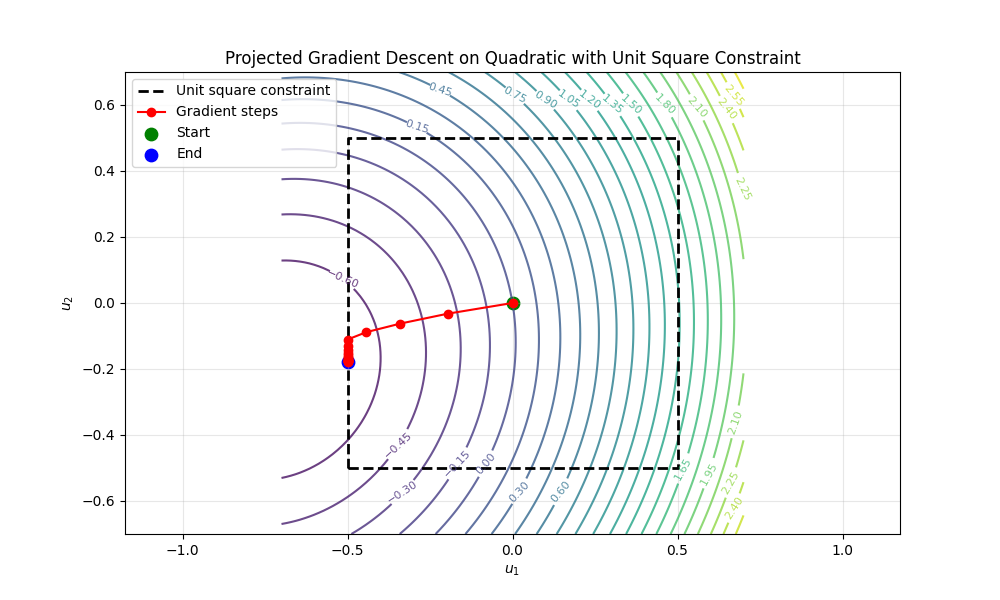

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Create a random 2D positive definite matrix H and 2D vector f
# np.random.seed(42)
A = np.random.randn(2, 2)
H = np.dot(A.T, A) + np.eye(2)  # Symmetric positive definite
f = np.random.randn(2)

# Define the objective function and its gradient
def obj(u):
    return 0.5 * u.T @ H @ u + f.T @ u

def grad(u):
    return H @ u + f

# Projection onto the square U = [-0.5, 0.5] x [-0.5, 0.5] (unit square centered at origin)
def project(u):
    return np.clip(u, -0.5, 0.5)

# Projected gradient descent parameters
u = np.zeros(2)
steps = 20
lr = 0.1
us = [u.copy()]  # Track the path

for _ in range(steps):
    u = u - lr * grad(u)
    u = project(u)
    us.append(u.copy())

us = np.stack(us)

# Plotting the steps of the algorithm
# Create a grid for contour/levels
U1, U2 = np.meshgrid(np.linspace(-0.7, 0.7, 100), np.linspace(-0.7, 0.7, 100))
Z = np.zeros_like(U1)
for i in range(U1.shape[0]):
    for j in range(U1.shape[1]):
        Z[i, j] = obj(np.array([U1[i, j], U2[i, j]]))

plt.figure(figsize=(10, 6))
# Plot the objective contours
contours = plt.contour(U1, U2, Z, levels=30, alpha=0.8, cmap='viridis')
plt.clabel(contours, inline=True, fontsize=8)

# Plot the constraint set (the unit square)
square = np.array([
    [-0.5, -0.5],
    [ 0.5, -0.5],
    [ 0.5,  0.5],
    [-0.5,  0.5],
    [-0.5, -0.5]
])
plt.plot(square[:,0], square[:,1], 'k--', lw=2, label='Unit square constraint')

# Plot the path of the projected gradient steps
plt.plot(us[:,0], us[:,1], 'ro-', label='Gradient steps')
plt.scatter(us[0,0], us[0,1], c='g', s=80, label='Start')
plt.scatter(us[-1,0], us[-1,1], c='b', s=80, label='End')

plt.xlabel('$u_1$')
plt.ylabel('$u_2$')
plt.title('Projected Gradient Descent on Quadratic with Unit Square Constraint')
plt.legend()
plt.axis('equal')
plt.grid(alpha=0.3)
plt.show()
